<a href="https://colab.research.google.com/github/Soviet117/lima-rent-predictive/blob/main/notebooks/02_Modelo_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# BLOQUE 1: CONFIGURACION INICIAL
# ============================================

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas")

# ============================================
# BLOQUE 2: CARGAR DATOS LIMPIOS
# ============================================

df = pd.read_csv('/content/drive/MyDrive/lima_rent/dataset_clean.csv')
print(f"Registros cargados: {df.shape}")
print("\nPrimeras filas:")
df.head()

Mounted at /content/drive
Librerías importadas
Registros cargados: (597, 19)

Primeras filas:


,titulo,ubicacion,distrito,zona,precio,precio_m2,precio_categoria,tipo_inmueble,tipo_operacion,dormitorios,banos,area,tamano_categoria,antiguedad,anio_construccion,mantenimiento,publicador,fecha_publicacion,url
0,Apartamento en alquiler en Ur. Santa Cruz,"Ur. Santa Cruz, Miraflores, Lima, Lima",Miraflores,Centro,900.0,8.737864,Moderado,Apartamento,Alquiler,2,2,103.0,Grande,16.0,2010,NaN,GARRIDO SECLEN RICARDY BUENAVENTURA,"Hace 1 semana, 1 día - Publicado por GARRIDO S...",https://www.properati.com.pe/detalle/14032-32-...
1,Apartamento en alquiler en Ur. San Luis,"Ur. San Luis, Barranco, Lima, Lima",Barranco,Sur,720.0,10.909091,Moderado,Apartamento,Alquiler,2,2,66.0,Mediano,6.0,2020,S/.150,JESUS ALTAMIRANO CONDEMARIN,26 mar. 2023 - Publicado por JESUS ALTAMIRANO ...,https://www.properati.com.pe/detalle/14032-32-...
2,Casa en alquiler en Chorrillos,"Chorrillos, Lima, Lima",Lima,Otro,2300.0,11.855670,Lujo,Casa,Alquiler,5,3,194.0,Grande,64.0,1962,S/.70,Century 21 Horizonte,20 mar. 2023 - Publicado por Century 21 Horizonte,https://www.properati.com.pe/detalle/14032-32-...
3,Apartamento en alquiler en Ba. S/N,"Ba. S/N, Rimac, Lima, Lima",Rimac,Otro,1200.0,8.955224,Alto,Apartamento,Alquiler,1,2,134.0,Grande,NaN,NaN,S/.650,KRB Agencia Perú,"Hace 4 días, 2 horas - Publicado por KRB Agenc...",https://www.properati.com.pe/detalle/14032-32-...
4,Apartamento en alquiler en Ur. Balta,"Ur. Balta, Miraflores, Lima, Lima",Miraflores,Centro,1450.0,7.837838,Alto,Apartamento,Alquiler,4,2,185.0,Grande,26.0,2000,S/.225,SOCIOS INMOBILIARIOS,7 feb. 2023 - Publicado por SOCIOS INMOBILIARIOS,https://www.properati.com.pe/detalle/14032-32-...


In [2]:
# ============================================
# BLOQUE 3: PREPROCESAMIENTO
# ============================================

# 1. Seleccionar características para el modelo
features = ['area', 'dormitorios', 'banos', 'antiguedad']
target = 'precio'

# 2. Eliminar registros con nulos en características clave
df_model = df[features + [target]].dropna()
print(f"Registros para modelo: {df_model.shape}")

# 3. Variables independientes (X) y dependiente (y)
X = df_model[features]
y = df_model[target]

print(f"\nCaracterísticas: {features}")
print(f"Target: {target}")

Registros para modelo: (455, 5)

Características: ['area', 'dormitorios', 'banos', 'antiguedad']
Target: precio


In [3]:
# ============================================
# BLOQUE 4: DIVIDIR EN TRAIN/TEST
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test: {X_test.shape[0]} registros")

Train: 364 registros
Test: 91 registros


In [4]:
# ============================================
# BLOQUE 5: ENTRENAR MODELO RANDOM FOREST
# ============================================

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("Modelo entrenado")

# Predicciones
y_pred = rf.predict(X_test)

# ============================================
# BLOQUE 6: METRICAS DEL MODELO
# ============================================

print("\n=== METRICAS DEL MODELO ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE (Error Absoluto Medio): S/. {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE (Raiz Error Cuadratico Medio): S/. {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Calcular error porcentual
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print(f"MAPE (Error Porcentual): {mape:.2f}%")

Modelo entrenado

=== METRICAS DEL MODELO ===
R² Score: -1.0670
MAE (Error Absoluto Medio): S/. 3109.95
RMSE (Raiz Error Cuadratico Medio): S/. 11840.79
MAPE (Error Porcentual): 201.27%



=== IMPORTANCIA DE CARACTERISTICAS ===
       feature  importance
0         area    0.613219
1  dormitorios    0.153089
3   antiguedad    0.136174
2        banos    0.097518


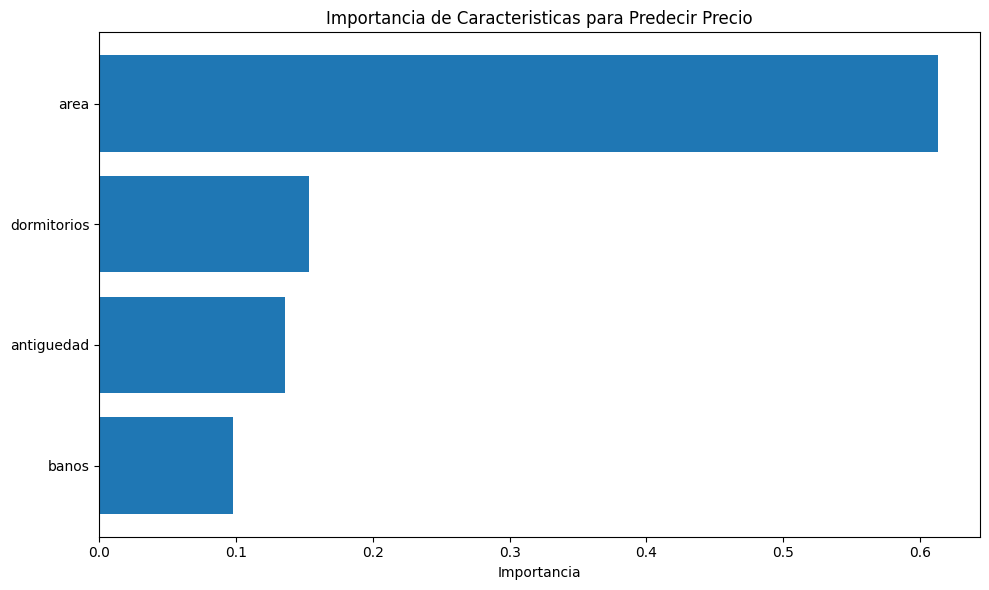

In [5]:
# ============================================
# BLOQUE 7: IMPORTANCIA DE FEATURES
# ============================================

importances = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== IMPORTANCIA DE CARACTERISTICAS ===")
print(importances)

# Visualizar importancia
plt.figure(figsize=(10, 6))
plt.barh(importances['feature'], importances['importance'])
plt.xlabel('Importancia')
plt.title('Importancia de Caracteristicas para Predecir Precio')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lima_rent/feature_importance.png')
plt.show()

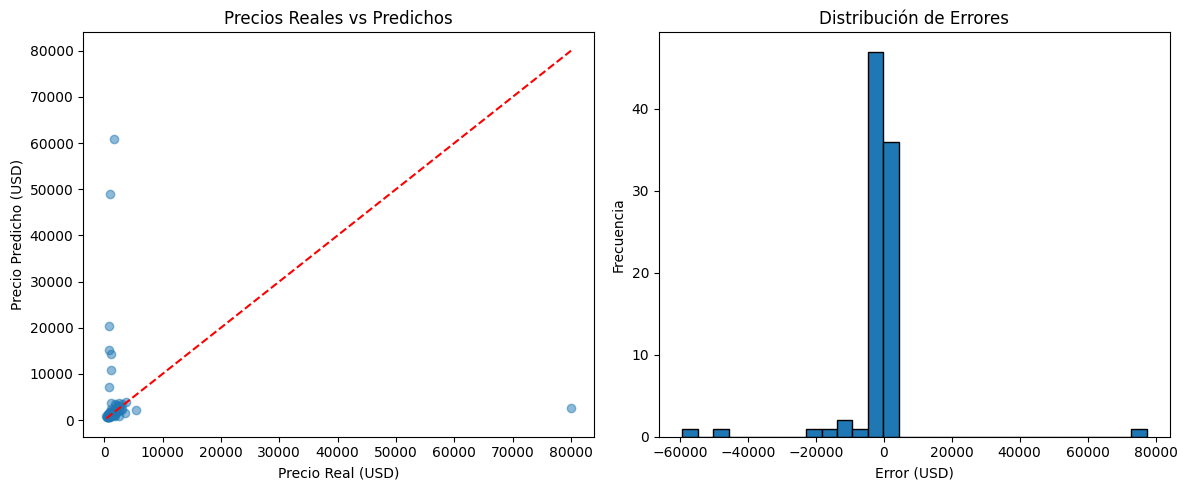

In [6]:
# ============================================
# BLOQUE 8: VISUALIZAR RESULTADOS
# ============================================

# Gráfico: Precios reales vs Predichos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Precio Real (USD)')
plt.ylabel('Precio Predicho (USD)')
plt.title('Precios Reales vs Predichos')

# Gráfico: Distribución de errores
plt.subplot(1, 2, 2)
residuos = y_test - y_pred
plt.hist(residuos, bins=30, edgecolor='black')
plt.xlabel('Error (USD)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Errores')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lima_rent/modelo_resultados.png')
plt.show()

In [7]:
# ============================================
# BLOQUE 9: ANALISIS POR ZONA
# ============================================

# Agregar zona al análisis
df_completo = df[['zona', 'precio']].dropna()
print("\n=== PRECIO PROMEDIO POR ZONA ===")
print(df_completo.groupby('zona')['precio'].mean().sort_values(ascending=False))

print("\n=== CANTIDAD DE REGISTROS POR ZONA ===")
print(df_completo.groupby('zona')['precio'].count().sort_values(ascending=False))


=== PRECIO PROMEDIO POR ZONA ===
zona
Otro      4571.835616
Oeste     2666.500000
Norte     1860.333333
Sur       1567.071429
Este      1507.250000
Centro    1373.258555
Name: precio, dtype: float64

=== CANTIDAD DE REGISTROS POR ZONA ===
zona
Centro    263
Otro      219
Este       64
Sur        42
Oeste       6
Norte       3
Name: precio, dtype: int64


In [8]:
# ============================================
# BLOQUE 10: GUARDAR MODELO
# ============================================

import joblib

# Guardar modelo entrenado
joblib.dump(rf, '/content/drive/MyDrive/lima_rent/modelo_random_forest.pkl')
print("Modelo guardado en: /content/drive/MyDrive/lima_rent/modelo_random_forest.pkl")

# Guardar caracteristicas usadas
with open('/content/drive/MyDrive/lima_rent/features_used.txt', 'w') as f:
    f.write(','.join(features))

print("Caracteristicas guardadas")

Modelo guardado en: /content/drive/MyDrive/lima_rent/modelo_random_forest.pkl
Caracteristicas guardadas


In [9]:
# ============================================
# VERIFICAR MODELO GUARDADO
# ============================================

import joblib
import pandas as pd

# Cargar el modelo
modelo = joblib.load('/content/drive/MyDrive/lima_rent/modelo_random_forest.pkl')

# Verificar tipo
print(f"Tipo de modelo: {type(modelo)}")

# Verificar características del modelo
print(f"Número de árboles: {modelo.n_estimators}")
print(f"Profundidad máxima: {modelo.max_depth}")
print(f"Features usadas: {modelo.feature_names_in_}")

# Hacer una predicción de prueba
X_prueba = pd.DataFrame({
    'area': [100],
    'dormitorios': [3],
    'banos': [2],
    'antiguedad': [10]
})

prediccion = modelo.predict(X_prueba)
print(f"\nPredicción de prueba (área=100, 3 dorm, 2 baños, 10 años): S/. {prediccion[0]:.2f}")
print("Modelo funciona correctamente")

Tipo de modelo: <class 'sklearn.ensemble._forest.RandomForestRegressor'>
Número de árboles: 200
Profundidad máxima: 15
Features usadas: ['area' 'dormitorios' 'banos' 'antiguedad']

Predicción de prueba (área=100, 3 dorm, 2 baños, 10 años): S/. 971.16
Modelo funciona correctamente
